<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a> |
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a> |
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a> |
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# **As Leis da Probabilidade - Conceitos e Aplicações**

## **Introdução**

Este notebook adota uma abordagem computacional para introduzir as leis da probabilidade. Usaremos dados da **General Social Survey (GSS)** para calcular probabilidades de proposições como:

* Qual é a probabilidade de que um entrevistado escolhido ao acaso seja mulher?
* Qual é a probabilidade de que um entrevistado escolhido ao acaso trabalhe no setor bancário?

A partir dessas perguntas, estudaremos dois conceitos centrais:

* **Conjunção**, isto é, a probabilidade de que duas proposições sejam simultaneamente verdadeiras.
* **Probabilidade condicional**, isto é, a probabilidade de que uma proposição seja verdadeira dado que outra já se sabe verdadeira.

Esses conceitos aparecem de forma clássica no experimento de Tversky e Kahneman conhecido como [falácia da conjunção](https://pt.wikipedia.org/wiki/Falácia_da_conjunção). No problema da Linda, compara-se a plausibilidade de duas afirmações:

> 1. Linda é caixa de banco.  
> 2. Linda é caixa de banco e participa do movimento feminista.  

Muitas pessoas consideram a segunda alternativa mais convincente, porque ela parece mais compatível com a descrição apresentada. No entanto, em termos probabilísticos, isso é impossível. Se definirmos

* $A$: "Linda é caixa de banco";
* $B$: "Linda participa do movimento feminista";

então a segunda alternativa corresponde ao evento conjunto $A \cap B$. Como todo elemento de $A \cap B$ também pertence a $A$, segue que

$$
P(A \cap B) \leq P(A).
$$

Portanto, a probabilidade de "Linda ser caixa de banco e feminista" não pode ser maior do que a probabilidade de "Linda ser caixa de banco". Esse erro de raciocínio é chamado de **falácia da conjunção**.

Ao longo desta seção, usaremos dados reais para mostrar como esse princípio aparece em exemplos concretos e como a linguagem booleana em Python ajuda a representar eventos, conjunções e probabilidades condicionais com clareza.

## **Probabilidade**

Para introduzir formalmente a probabilidade, precisamos de dois conceitos básicos. O primeiro é o **espaço amostral**, que representa o conjunto de todos os resultados possíveis de um experimento aleatório. O segundo é o **evento**, isto é, qualquer subconjunto do espaço amostral ao qual podemos associar uma probabilidade.

No caso de um conjunto finito de resultados equiprováveis, a probabilidade de um evento $A$ pode ser definida por

$$
P(A) = \frac{n(A)}{n(\Omega)},
$$

em que $n(A)$ é o número de resultados favoráveis ao evento e $n(\Omega)$ é o número total de resultados possíveis no espaço amostral $\Omega$.

De forma mais geral, a probabilidade deve obedecer aos **axiomas fundamentais**:

* Para qualquer evento $A$, tem-se $P(A) \geq 0$.
* A probabilidade do espaço amostral é 1, isto é, $P(\Omega)=1$.
* Se $A$ e $B$ forem eventos mutuamente exclusivos, então $P(A \cup B)=P(A)+P(B)$.

Esses axiomas, apresentados em textos introdutórios como o de Barbetta, servem de base para todas as demais propriedades da probabilidade.

No contexto deste notebook, adotaremos uma interpretação operacional compatível com esses princípios: uma **probabilidade** será calculada como a **fração** de elementos de um conjunto de dados que satisfazem determinada condição.

Sob a **interpretação frequencista**, a probabilidade de um evento pode ser entendida como o valor em torno do qual a **frequência relativa** desse evento tende a se estabilizar quando o experimento é repetido muitas vezes, sob as mesmas condições. Assim, a fração observada em um conjunto de dados pode ser vista como uma **estimativa empírica** da probabilidade teórica, e essa estimativa tende a melhorar à medida que o número de observações aumenta.

Por exemplo, se entrevistarmos 1000 pessoas e 20 delas trabalharem no setor bancário, então a fração correspondente é $20/1000 = 0{,}02$, ou seja, 2%. Se escolhermos uma pessoa dessa população ao acaso, a probabilidade de que ela trabalhe no setor bancário será 2%.

Ao dizer "ao acaso", estamos assumindo que todos os elementos do conjunto de dados têm a mesma chance de serem selecionados. Com essa interpretação e um conjunto de dados apropriado, podemos calcular probabilidades por contagem.

Para demonstrar, usaremos um conjunto de dados da [General Social Survey](http://gss.norc.org/) ou GSS. A célula a seguir lê os dados.

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Uma forma simples de visualizar essa ideia é simular repetidos lançamentos de um **dado justo** e acompanhar a **frequência relativa** do evento "sair 6". Nesse caso, a probabilidade teórica do evento é $1/6$.

À medida que o número de lançamentos cresce, esperamos que a frequência relativa observada se aproxime desse valor teórico.

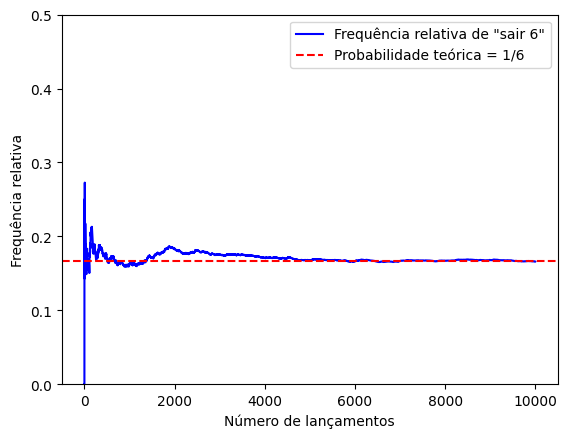

In [2]:
# Simulando a frequência relativa do evento "sair 6"
# em lançamentos de um dado justo
n = 10000
gerador = np.random.default_rng(1)
lancamentos = gerador.integers(1, 7, size=n)
evento_seis = (lancamentos == 6)
frequencia_relativa = np.cumsum(evento_seis) / np.arange(1, n + 1)

plt.plot(
    frequencia_relativa,
    color="blue",
    label='Frequência relativa de "sair 6"'
)
plt.axhline(
    y=1/6,
    color="red",
    linestyle="--",
    label="Probabilidade teórica = 1/6"
)
plt.xlabel("Número de lançamentos")
plt.ylabel("Frequência relativa")
plt.ylim(0, 0.5)
plt.legend()
plt.show()

**Fig. 1 - Frequência relativa do evento "sair 6" em lançamentos de um dado justo**. O gráfico mostra que, à medida que o número de lançamentos aumenta, a frequência relativa observada tende a se aproximar da probabilidade teórica de $1/6$. Fonte: Carubbo, 2026.

In [3]:
# Carregando o dataset
gss = pd.read_csv('../../dataset/gss_bayes.csv')
gss.head()

,caseid,year,age,sex,polviews,partyid,indus10
0,1,1974,21.0,1,4.0,2.0,4970.0
1,2,1974,41.0,1,5.0,0.0,9160.0
2,5,1974,58.0,2,6.0,1.0,2670.0
3,6,1974,30.0,1,5.0,4.0,6870.0
4,7,1974,48.0,1,5.0,4.0,7860.0


In [4]:
# Renomeando as colunas para facilitar a manipulação
gss.rename(columns={
    'caseid': 'id',
    'year': 'ano',
    'age': 'idade',
    'sex': 'sexo',
    'polviews': 'visao_pol',
    'partyid': 'partido',
    'indus10': 'setor',
}, inplace=True)

gss.head()

,id,ano,idade,sexo,visao_pol,partido,setor
0,1,1974,21.0,1,4.0,2.0,4970.0
1,2,1974,41.0,1,5.0,0.0,9160.0
2,5,1974,58.0,2,6.0,1.0,2670.0
3,6,1974,30.0,1,5.0,4.0,6870.0
4,7,1974,48.0,1,5.0,4.0,7860.0


In [5]:
# Convertendo as colunas 'visao_pol' e 'partido' para o tipo inteiro
cols_int = ['visao_pol', 'partido', 'setor']
for col in cols_int:
    gss[col] = gss[col].astype(int)

gss.head()

,id,ano,idade,sexo,visao_pol,partido,setor
0,1,1974,21.0,1,4,2,4970
1,2,1974,41.0,1,5,0,9160
2,5,1974,58.0,2,6,1,2670
3,6,1974,30.0,1,5,4,6870
4,7,1974,48.0,1,5,4,7860


In [6]:
# Exibindo informações básicas sobre o dataset
gss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49290 entries, 0 to 49289
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         49290 non-null  int64  
 1   ano        49290 non-null  int64  
 2   idade      49290 non-null  float64
 3   sexo       49290 non-null  int64  
 4   visao_pol  49290 non-null  int64  
 5   partido    49290 non-null  int64  
 6   setor      49290 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 2.6 MB


As colunas são:

* `id`: identificador do respondente; variável identificadora.
* `ano`: ano da entrevista; variável quantitativa discreta.
* `idade`: idade do respondente na entrevista; variável quantitativa discreta.
* `sexo`: sexo do respondente; variável categórica nominal.
* `visao_pol`: posicionamento político em uma escala de liberal a conservador; variável categórica ordinal.
* `partido`: identificação partidária do respondente; variável categórica nominal.
* `setor`: [código](https://www.census.gov/cgi-bin/sssd/naics/naicsrch?chart=2007) do setor de atividade econômica em que o respondente trabalha; variável categórica nominal.

Vamos analisar essas variáveis em mais detalhes, começando por `setor`.

## Setor Bancário

O código para "Atividades bancárias e relacionadas" é 6870, então podemos selecionar os bancários assim:

In [7]:
# Criando a série 'setor_bancario' para identificar
# os respondentes que trabalham no setor bancário (setor 6870)
setor_bancario = (gss['setor'] == 6870)

O resultado é uma série booleana, que é uma Series do Pandas contendo os valores `True` e `False`. Aqui estão as primeiras entradas:

In [8]:
# Exibindo as primeiras linhas da série 'setor_bancario'
setor_bancario.head()

0    False
1    False
2    False
3     True
4    False
Name: setor, dtype: bool

Podemos usar `values` para ver quantas vezes cada valor aparece.

In [9]:
# Contando o número de True e False na série 'setor_bancario'
setor_bancario.value_counts()

setor
False    48562
True       728
Name: count, dtype: int64

Neste conjunto de dados, há 728 bancários.

Se usarmos a função `sum` nesta Series, ela trata `True` como 1 e `False` como 0, então o total corresponde ao número de bancários.

In [10]:
setor_bancario.sum()

np.int64(728)

| Booleano | Inteiro |
| --- | ---: |
| `False` | 0 |
| `True` | 1 |
| `False` | 0 |
| `False` | 0 |
| `True` | 1 |
| `...` | `...` |
| `False` | 0 |

Total: `728`

**Tab. 1 - Conversão de valores booleanos em inteiros**. A tabela mostra
como os valores lógicos `False` e `True` podem ser representados por
`0` e `1`, respectivamente, o que permite calcular contagens e
proporções por soma e média em séries booleanas. Fonte: Carubbo,
2026.

Para calcular a *fração* de bancários, podemos dividir pelo número de pessoas no conjunto de dados:

In [11]:
setor_bancario.sum() / setor_bancario.size

np.float64(0.014769730168391155)

Mas também podemos usar a função `mean`, que calcula a fração de valores `True` na Series:

In [12]:
setor_bancario.mean()

np.float64(0.014769730168391155)

Cerca de 1,5% dos entrevistados trabalham no setor bancário.

Isso significa que, se escolhermos um entrevistado aleatório da pesquisa, a probabilidade de que seja bancário é de aproximadamente 1,5%.

**Exercício**: Os valores da coluna `sexo` são codificados assim:

```
1    Masculino
2    Feminino
```

A célula a seguir cria uma série booleana que é `True` para entrevistadas do sexo feminino e `False` caso contrário.

In [13]:
feminino = (gss['sexo'] == 2)

* Use `values` para exibir o número de valores `True` e `False` em `feminino`.

* Use `sum` para contar o número de entrevistadas.

* Use `mean` para calcular a fração de entrevistadas.

In [14]:
feminino.value_counts()

sexo
True     26511
False    22779
Name: count, dtype: int64

In [15]:
feminino.sum()

np.int64(26511)

In [16]:
feminino.mean()

np.float64(0.5378575776019476)

A fração de mulheres neste conjunto de dados é maior do que na população adulta dos EUA porque [a GSS não inclui pessoas que vivem em instituições](https://gss.norc.org/faq), como prisões e habitações militares, e essas populações tendem a ser majoritariamente masculinas.

**Exercício:** Os responsáveis pela pesquisa decidiram representar sexo como uma variável binária. Que alternativas eles poderiam ter considerado? Quais são as vantagens e desvantagens dessa escolha?

Para saber mais sobre este tema, você pode se interessar por este artigo: Westbrook e Saperstein, [Novas categorias não são suficientes: repensando a mensuração de sexo e gênero em pesquisas sociais](https://sci-hub.tw/10.1177/0891243215584758)

## Visões políticas

Os valores de `visao_pol` estão em uma escala de sete pontos:

```
1    Extremamente liberal
2    Liberal
3    Ligeiramente liberal
4    Moderado
5    Ligeiramente conservador
6    Conservador
7    Extremamente conservador
```

Aqui está o número de pessoas que deram cada resposta:

In [17]:
# Contando o número de True e False na série 'visao_pol'
gss['visao_pol'].value_counts()

visao_pol
4    18943
5     7940
6     7319
3     6243
2     5808
7     1595
1     1442
Name: count, dtype: int64

Vou definir `liberal` como `True` para qualquer pessoa cuja resposta seja "Extremamente liberal", "Liberal" ou "Ligeiramente liberal".

In [18]:
# Criando a série 'liberal' para identificar
# os respondentes que se consideram liberais
liberal = (gss['visao_pol'] < 4)

Aqui estão as quantidades de valores `True` e `False`:

In [19]:
# Contando o número de True e False na série 'liberal'
liberal.value_counts()

visao_pol
False    35797
True     13493
Name: count, dtype: int64

E a fração de entrevistados que são "liberais".

In [20]:
liberal.sum() / liberal.size

np.float64(0.27374721038750255)

In [21]:
liberal.mean()

np.float64(0.27374721038750255)

Se escolhermos um entrevistado aleatório da pesquisa neste conjunto de dados, a probabilidade de que seja liberal é de aproximadamente 27%.

## A função de probabilidade

Para resumir o que fizemos até agora:

* Para representar uma proposição lógica como "este entrevistado é liberal", estamos usando uma série booleana, que contém os valores `True` e `False`.

* Para calcular a probabilidade de que uma proposição seja verdadeira, estamos usando a função `mean`, que calcula a fração de valores `True` em uma série.

Para tornar esse cálculo mais explícito, vou definir uma função que recebe uma série booleana e retorna uma probabilidade:

In [22]:
def prob(A):
    """Calcula a probabilidade de uma proposição A.
    A: série booleana
    retorna: probabilidade
    """
    assert isinstance(A, pd.Series)
    assert A.dtype == 'bool'

    return A.sum()/A.size # equivalente a A.mean()

As instruções `assert` verificam se `A` é uma série booleana. Caso contrário, exibem uma mensagem de erro.

Do ponto de vista matemático, `prob(A)` representa a probabilidade do
evento `A`, calculada como a fração de entrevistados para os quais a
série booleana `A` assume valor `True`.

Usar essa função para calcular probabilidades torna o código mais
legível. Aqui estão as probabilidades para as proposições que
calculamos até agora.

In [23]:
# Calculando a probabilidade de um respondente trabalhar no setor bancário
prob(setor_bancario)

np.float64(0.014769730168391155)

In [24]:
# Calculando a probabilidade de um respondente ser do sexo feminino
prob(feminino)

np.float64(0.5378575776019476)

In [25]:
# Calculando a probabilidade de um respondente se considerar liberal
prob(liberal)

np.float64(0.27374721038750255)

**Exercício**: Os valores de `partido` são codificados assim:

```
0    Democrata convicto
1    Democrata não convicto
2    Independente, próximo dos democratas
3    Independente
4    Independente, próximo dos republicanos
5    Republicano não convicto
6    Republicano convicto
7    Outro partido
```

Vou definir `democratas` para incluir os entrevistados que escolheram "Democrata convicto" ou "Democrata não convicto":

In [26]:
democrata = (gss['partido'] <= 1)

* Use `mean` para calcular a fração de democratas neste conjunto de dados.

* Use `prob` para calcular a mesma fração, que vamos interpretar como uma probabilidade.

In [27]:
democrata.mean()

np.float64(0.3662609048488537)

In [28]:
prob(democrata)

np.float64(0.3662609048488537)

Também podemos representar o **espaço amostral** como a união de um evento e seu complemento. No caso abaixo, a barra inteira representa todos os entrevistados, e os dois segmentos mostram a partição entre **democratas** e **não democratas**.

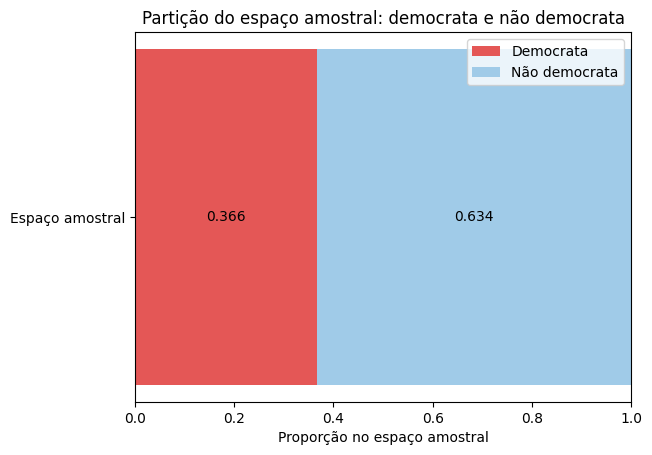

In [29]:
# Organiza as probabilidades do evento e de seu complemento
p_democrata = prob(democrata)
p_nao_democrata = prob(~democrata)

# Desenha uma barra horizontal empilhada para representar o espaço amostral
plt.barh(
    ['Espaço amostral'],
    [p_democrata],
    color='#E45756',
    label='Democrata'
)
plt.barh(
    ['Espaço amostral'],
    [p_nao_democrata],
    left=[p_democrata],
    color='#A0CBE8',
    label='Não democrata'
)

# Adiciona rótulos aos dois segmentos da barra
plt.text(
    p_democrata / 2,
    0,
    f'{p_democrata:.3f}',
    ha='center',
    va='center'
)
plt.text(
    p_democrata + p_nao_democrata / 2,
    0,
    f'{p_nao_democrata:.3f}',
    ha='center',
    va='center'
)

plt.xlim(0, 1)
plt.xlabel('Proporção no espaço amostral')
plt.title('Partição do espaço amostral: democrata e não democrata')
plt.legend()
plt.show()

**Fig. 2 - Partição do espaço amostral entre democratas e não democratas**. A barra inteira representa o espaço amostral e os dois segmentos mostram um evento e seu complemento, evidenciando que suas proporções somam 1. Fonte: Carubbo, 2026.

O gráfico a seguir resume algumas **probabilidades simples** já definidas no notebook. Ele ajuda a visualizar a função `prob` como uma proporção observada no conjunto de dados.

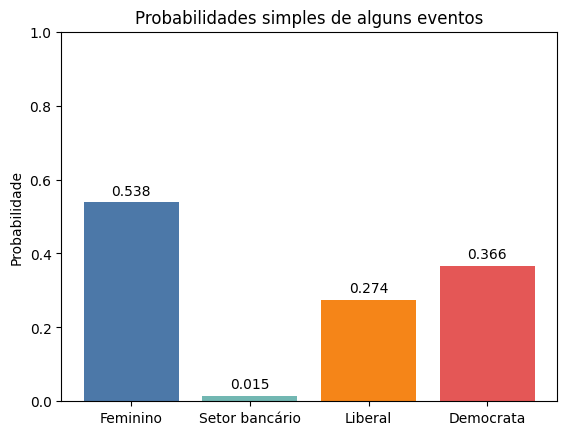

In [30]:
# Organiza as probabilidades simples que serão comparadas no gráfico
eventos = {
    'Feminino': prob(feminino),
    'Setor bancário': prob(setor_bancario),
    'Liberal': prob(liberal),
    'Democrata': prob(democrata),
}

# Desenha o gráfico de barras das probabilidades simples
barras = plt.bar(
    eventos.keys(),
    eventos.values(),
    color=['#4C78A8', '#72B7B2', '#F58518', '#E45756']
)

# Adiciona rótulos numéricos sobre cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.02,
        f'{altura:.3f}',
        ha='center'
    )
plt.ylabel('Probabilidade')
plt.ylim(0, 1)
plt.title('Probabilidades simples de alguns eventos')
plt.show()

**Fig. 3 - Probabilidades simples de alguns eventos**. O gráfico compara proporções observadas de eventos isolados no conjunto de dados, reforçando a interpretação de probabilidade como fração de casos favoráveis no espaço amostral. Fonte: Carubbo, 2026.

## Conjunção

Agora que temos uma definição de probabilidade e uma função que a calcula, vamos seguir para a conjunção.

"Conjunção" é outro nome para a operação lógica `and`. Se você tiver duas proposições, `A` e `B`, a conjunção `A and B` é `True` se tanto `A` quanto `B` forem `True`, e `False` caso contrário.

Em notação de probabilidade, essa combinação corresponde ao evento
conjunto `A \cap B`. No código, escrevemos esse evento como `A & B`,
e sua probabilidade conjunta é calculada por `prob(A & B)`.

Vou demonstrar usando duas séries booleanas construídas para enumerar todas as combinações de `True` e `False`:

In [31]:
# Série booleana A de exemplo
A = pd.Series((True, True, False, False))
A

0     True
1     True
2    False
3    False
dtype: bool

In [32]:
# Série booleana B de exemplo
B = pd.Series((True, False, True, False))
B

0     True
1    False
2     True
3    False
dtype: bool

Para calcular a conjunção de `A` e `B`, podemos usar o operador `&`, assim:

In [33]:
# Resultado das séries booleanas A e B
A & B

0     True
1    False
2    False
3    False
dtype: bool

O resultado é `True` apenas quando `A` e `B` são `True`.

Para mostrar essa operação com mais clareza, colocarei os operandos e o resultado em um DataFrame:

In [34]:
# Tabela verdade para A & B
table = pd.DataFrame()
table['A'] = A
table['B'] = B
table['A & B'] = A & B
table

,A,B,A & B
0,True,True,True
1,True,False,False
2,False,True,False
3,False,False,False


Essa forma de representar uma operação lógica é chamada de [tabela verdade](https://en.wikipedia.org/wiki/Truth_table).

Na seção anterior, calculamos a probabilidade de que um entrevistado aleatório da pesquisa seja bancário:

In [35]:
prob(setor_bancario)

np.float64(0.014769730168391155)

E a probabilidade de que um entrevistado seja democrata:

In [36]:
prob(democrata)

np.float64(0.3662609048488537)

Agora podemos calcular a probabilidade de que um entrevistado aleatório da pesquisa seja bancário *e* democrata:

In [37]:
prob(setor_bancario & democrata)

np.float64(0.004686548995739501)

Como era de se esperar, `prob(setor_bancario & democrata)` é menor que `prob(setor_bancario)`, porque nem todos os trabalhadores do setor bancário são democratas.

Também podemos visualizar essa ideia comparando duas probabilidades marginais com a probabilidade da **conjunção** correspondente.

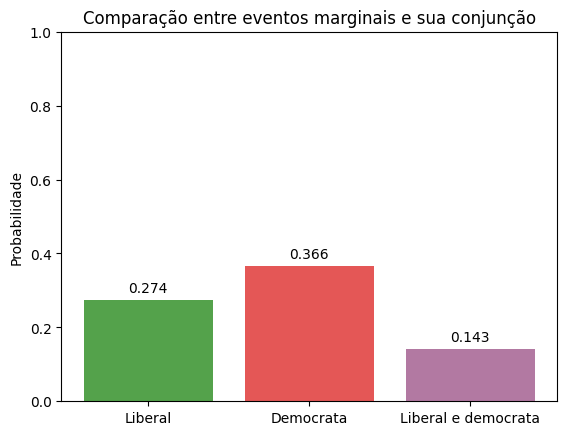

In [38]:
# Gráfico comparando as probabilidades dos eventos marginais e da conjunção
eventos_conjuncao = {
    'Liberal': prob(liberal),
    'Democrata': prob(democrata),
    'Liberal e democrata': prob(liberal & democrata),
}

# Desenha o gráfico de barras para comparar eventos marginais e conjunção
barras = plt.bar(
    eventos_conjuncao.keys(),
    eventos_conjuncao.values(),
    color=['#54A24B', '#E45756', '#B279A2']
)

# Adiciona rótulos numéricos sobre cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.02,
        f'{altura:.3f}',
        ha='center'
    )
plt.ylabel('Probabilidade')
plt.ylim(0, 1)
plt.title('Comparação entre eventos marginais e sua conjunção')
plt.show()

**Fig. 4 - Comparação entre eventos marginais e sua conjunção**. O gráfico evidencia que a probabilidade da conjunção `liberal e democrata` é menor do que as probabilidades dos eventos marginais, em conformidade com a lógica da interseção de eventos. Fonte: Carubbo, 2026.

**Exercício:** Use `prob` e o operador `&` para calcular as seguintes probabilidades.

* Qual é a probabilidade de que um entrevistado aleatório da pesquisa seja bancário e liberal?

* Qual é a probabilidade de que um entrevistado aleatório da pesquisa seja mulher, bancária e liberal?

* Qual é a probabilidade de que um entrevistado aleatório da pesquisa seja mulher, bancária e democrata liberal?

Note que, à medida que adicionamos mais conjunções, as probabilidades ficam menores.

In [39]:
prob(setor_bancario & liberal)

np.float64(0.003306958815175492)

In [40]:
prob(feminino & setor_bancario & liberal)

np.float64(0.002556299452221546)

In [41]:
prob(feminino & setor_bancario & liberal & democrata)

np.float64(0.0012375735443294787)

**Exercício:** Esperamos que a conjunção seja comutativa; ou seja, `A & B` deve ser o mesmo que `B & A`.

Para verificar, calcule estas duas probabilidades:

* Qual é a probabilidade de que um entrevistado aleatório da pesquisa seja bancário e liberal?  
* Qual é a probabilidade de que um entrevistado aleatório da pesquisa seja liberal e bancário?

In [42]:
prob(setor_bancario & liberal)

np.float64(0.003306958815175492)

In [43]:
prob(liberal & setor_bancario)

np.float64(0.003306958815175492)

Se elas não forem iguais, algo deu muito errado!

## **Probabilidade condicional**

A **probabilidade condicional** quantifica a chance de ocorrência de um evento $A$ sob a condição de que outro evento $B$ já tenha ocorrido. Formalmente, para $P(B) > 0$, definimos

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}.
$$

Essa expressão mostra que a probabilidade condicional pode ser interpretada como a proporção de casos em que **$A$ e $B$ ocorrem simultaneamente** entre todos os casos em que **$B$ ocorre**.

Aqui estão alguns exemplos:

* Qual é a probabilidade de que um entrevistado seja democrata, dado que é liberal?
* Qual é a probabilidade de que um entrevistado seja mulher, dado que trabalha no setor bancário?
* Qual é a probabilidade de que um entrevistado seja liberal, dado que é mulher?

Vamos começar com a primeira, que podemos interpretar assim: "De todos os entrevistados que são liberais, qual fração é democrata?"

No contexto do DataFrame, podemos calcular essa probabilidade em dois passos:

1. Selecionar todos os entrevistados que satisfazem a condição $B$; neste caso, os entrevistados liberais.  
2. Calcular, dentro desse subconjunto, a fração dos que também satisfazem o evento $A$; neste caso, os entrevistados democratas.  

Para selecionar os entrevistados liberais, podemos usar o operador de colchetes `[]`, assim:

In [44]:
selecionados = democrata[liberal]

O resultado é uma série booleana que contém um subconjunto dos valores em `democrata`. Especificamente, contém apenas os valores em que `liberal` é `True`.

Em termos de notação, estamos restringindo a análise aos casos em que
`B` ocorre, com `B` = "ser liberal", para então observar, dentro
desse subconjunto, quando também ocorre `A`, com `A` = "ser
democrata".

Para confirmar, vamos verificar o tamanho do resultado:

In [45]:
len(selecionados)

13493

Se tudo saiu como o esperado, isso deve ser igual ao número de valores `True` em `liberal`:

In [46]:
liberal.sum()

np.int64(13493)

Ótimo.  

`selecionados` contém o valor de `democrata` para os entrevistados
liberais, então a média de `selecionados` é a fração de liberais que
são democratas, isto é, `P(A|B)` com `A` = "ser democrata" e
`B` = "ser liberal":

In [47]:
selecionados.mean()

np.float64(0.5206403320240125)

In [48]:
# Usando a definição de probabilidade condicional
prob(democrata & liberal) / prob(liberal)

np.float64(0.5206403320240124)

Um pouco mais da metade dos liberais são democratas. Se o resultado for menor do que você esperava, lembre-se:

1. Usamos uma definição relativamente restrita de "Democrata", excluindo os independentes que "tendem" para os democratas.  

2. O conjunto de dados inclui entrevistados desde 1974; no início desse período havia menos alinhamento entre visões políticas e filiação partidária, em comparação com o presente.

Vamos tentar o segundo exemplo: "Qual é a probabilidade de que um entrevistado seja mulher, dado que trabalha no setor bancário?"

Podemos interpretar isso como: "De todos os entrevistados que trabalham no setor bancário, qual fração é de mulheres?"

Novamente, usaremos o operador de colchetes para selecionar apenas os trabalhadores do setor bancário:

In [49]:
selecionados = feminino[setor_bancario]
len(selecionados)

728

Como vimos, há 728 bancários no conjunto de dados.

Agora podemos usar `mean` para calcular a probabilidade condicional de que um entrevistado seja mulher, dado que é bancário:

In [50]:
selecionados.mean()

np.float64(0.7706043956043956)

Cerca de 77% dos trabalhadores do setor bancário neste conjunto de dados são mulheres.

Podemos obter o mesmo resultado usando `prob`:

In [51]:
prob(selecionados)

np.float64(0.7706043956043956)

In [52]:
prob(feminino & setor_bancario) / prob(setor_bancario)

np.float64(0.7706043956043956)

Lembre-se de que definimos `prob` para tornar o código mais legível. Podemos fazer a mesma coisa com probabilidade condicional.

Vou definir `prob_cond` para receber duas séries booleanas, `A` e `B`, e calcular a probabilidade condicional de `A` dado `B`:

In [53]:
def prob_cond(A, B):
    """Calcula a probabilidade condicional de A dado B.

    A: série booleana
    B: série booleana

    retorna: probabilidade
    """
    return prob(A[B])

Agora podemos usá-la para calcular a probabilidade de que um liberal
seja democrata, isto é, `P(A|B)` com `A` = "ser democrata" e
`B` = "ser liberal":

In [54]:
prob_cond(democrata, liberal)

np.float64(0.5206403320240125)

E a probabilidade de que um bancário seja mulher:

In [55]:
prob_cond(feminino, setor_bancario)

np.float64(0.7706043956043956)

Os resultados são os mesmos que calculamos acima.

O próximo gráfico compara uma **probabilidade marginal** com uma **probabilidade condicional**. A diferença entre as barras mostra como a condição altera o espaço de referência do cálculo.

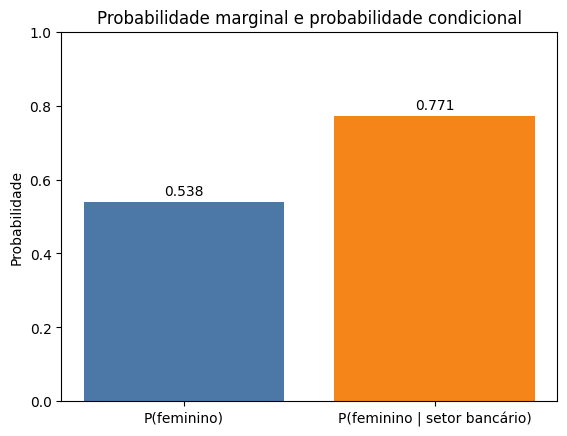

In [56]:
# Organiza a probabilidade marginal e a condicional a serem comparadas
eventos_condicionais = {
    'P(feminino)': prob(feminino),
    'P(feminino | setor bancário)': prob_cond(feminino, setor_bancario),
}

# Desenha o gráfico de barras comparando os dois tipos de probabilidade
barras = plt.bar(
    eventos_condicionais.keys(),
    eventos_condicionais.values(),
    color=['#4C78A8', '#F58518']
)

# Adiciona rótulos numéricos sobre cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.02,
        f'{altura:.3f}',
        ha='center'
    )
plt.ylabel('Probabilidade')
plt.ylim(0, 1)
plt.title('Probabilidade marginal e probabilidade condicional')
plt.show()

**Fig. 5 - Comparação entre probabilidade marginal e probabilidade condicional**. O gráfico mostra que a probabilidade de ser feminino muda quando restringimos o espaço de referência aos trabalhadores do setor bancário, ilustrando o efeito do condicionamento. Fonte: Carubbo, 2026.

**Exercício:** Use `prob_cond` para calcular a probabilidade de que um entrevistado seja liberal, dado que é mulher.

Dica: A resposta deve ser menor que 30%. Se o seu resultado for próximo de 54%, você cometeu um erro (veja o próximo exercício).

In [57]:
prob_cond(liberal, feminino)

np.float64(0.27581004111500884)

**Exercício:** Em um exercício anterior, vimos que a conjunção é comutativa; ou seja, `prob(A & B)` é sempre igual a `prob(B & A)`.

Mas a probabilidade condicional NÃO é comutativa; ou seja, `prob_cond(A, B)` não é o mesmo que `prob_cond(B, A)`.

Isso deve ficar claro se olharmos para um exemplo. Anteriormente, calculamos a probabilidade de que um entrevistado fosse mulher, dado que trabalhava no setor bancário.

In [58]:
prob_cond(feminino, setor_bancario)

np.float64(0.7706043956043956)

O resultado mostra que a maioria dos trabalhadores do setor bancário são mulheres. Mas isso não é o mesmo que a probabilidade de que um entrevistado trabalhe no setor bancário, dado que é mulher:

In [59]:
# Probabilidade de uma mulher trabalhar no setor bancário
prob_cond(setor_bancario, feminino)

np.float64(0.02116102749801969)

Apenas cerca de 2% das entrevistadas trabalham no setor bancário.

**Exercício:** Use `prob_cond` para calcular as seguintes probabilidades:

* Qual é a probabilidade de que um entrevistado seja liberal, dado que é democrata?

* Qual é a probabilidade de que um entrevistado seja democrata, dado que é liberal?

Pense com cuidado sobre a ordem das séries que você passa para `prob_cond`.

In [60]:
prob_cond(liberal, democrata)

np.float64(0.3891320002215698)

In [61]:
prob_cond(democrata, liberal)

np.float64(0.5206403320240125)

## Condições e conjunções

Podemos combinar probabilidade condicional e conjunção. Quando o
evento condicionante também é uma conjunção, basta construí-lo com o
operador `&`.

Por exemplo, se `A` = "ser mulher" e `B` = "ser democrata e
liberal", então `B` é representado por `democrata & liberal` e a
quantidade de interesse é `P(A|B)`.

In [62]:
# Probabilidade de uma mulher ser democrata liberal
prob_cond(feminino, liberal & democrata)

np.float64(0.576085409252669)

Quase 57% dos democratas liberais são mulheres.

Agora trocamos os papéis dos eventos. Se `A` = "ser mulher liberal"
e `B` = "trabalhar no setor bancário", então queremos calcular
`P(A|B)`.

E aqui está a probabilidade de que sejam mulheres liberais, dado que trabalham no setor bancário:

In [63]:
# Probabilidade de um bancário ser mulher liberal
prob_cond(liberal & feminino, setor_bancario)

np.float64(0.17307692307692307)

Cerca de 17% dos trabalhadores do setor bancário são mulheres liberais.

**Exercício:** Qual fração das mulheres que trabalham no setor bancário são democratas liberais?

Dica: Se sua resposta for menor que 1%, você inverteu a ordem. Lembre-se de que a probabilidade condicional não é comutativa.

In [64]:
prob_cond(liberal & democrata, feminino & setor_bancario)

np.float64(0.10873440285204991)

## **Resumo**

Neste ponto, você deve compreender a definição de probabilidade, pelo menos no caso simples em que temos um conjunto de dados finito. Mais adiante, consideraremos casos em que a definição de probabilidade é mais controversa.

E você deve compreender conjunção e probabilidade condicional. [No próximo notebook](https://colab.research.google.com/github/AllenDowney/BiteSizeBayes/blob/master/02_bayes.ipynb), exploraremos a relação entre conjunção e probabilidade condicional e a usaremos para deduzir o Teorema de Bayes, que é a base da estatística Bayesiana.

## **Citação**

Estas aulas são baseadas em [Bite Size Bayes](https://allendowney.github.io/BiteSizeBayes/), uma introdução à probabilidade e à estatística Bayesiana usando Python. Copyright 2020 Allen B. Downey

<p align="left">
  <a href="https://creativecommons.org/licenses/by-sa/4.0/" target="_blank" rel="noopener noreferrer">
    <img src="imgs/cc.png" width="75" alt="Licença Creative Commons BY-SA 4.0">
  </a>
</p>

Você pode utilizar este projeto livremente sob a Licença Creative Commons Atribuição-CompartilhaIgual 4.0 Internacional.